In [52]:
import torch
import torch.nn as nn
import torchvision
from torchvision.datasets import CIFAR10

In [53]:
# Data sets and Data Loaders

from torch.utils.data import DataLoader

import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

In [54]:
trainset = CIFAR10(root='./data',train=True,download=True,transform=transform)

testset = CIFAR10(root='./data',train=False,download=True,transform=transform)

In [55]:
trainloader = DataLoader(trainset,batch_size=64,shuffle=True)
testloader = DataLoader(testset,batch_size=64)

In [56]:
# Build the CNN

class CNN(nn.Module):
    def __init__(self):

        super(CNN,self).__init__()

        self.conv_layers = nn.Sequential(
            #1st layer
            #input channel as images are colored =3, o/p neurons= 32
            nn.Conv2d(3, 32,kernel_size=3,padding=1),
            nn.ReLU(),
            #Kernel size, stride == 2 in maxpool
            #MaxPool will half our image from 32*32*32 to 16*16*32
            nn.MaxPool2d(2,2),

            #2nd layer
            #o/p of 1st layer is input here = 32
            nn.Conv2d(32, 64,kernel_size=3,padding=1),
            nn.ReLU(),
            #MaxPool will half our image from 16*16*64 to 8*8*64
            nn.MaxPool2d(2,2),

            #3rd layer
            nn.Conv2d(64, 128,kernel_size=3,padding=1),
            nn.ReLU(),
            #MaxPool will half our image from 8*8*128 to 4*4*128
            nn.MaxPool2d(2,2)
        )

        self.fc_layers = nn.Sequential(
            #i/p layer
            #o/p image produced after 3rd layer in convo-layer
            nn.Linear(4*4*128,256),
            nn.ReLU(),

            #o/p layer
            nn.Linear(256,10)
        )

    def forward(self,x):
        x = self.conv_layers(x)

        #falttening to 1d from 2d, before enetering into fc_layers
        x = x.view(x.size(0),-1)

        x = self.fc_layers(x)
        return x

In [57]:
import torch.optim as optim

model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [58]:
# Train the CNN

epochs = 10
losses = []
for epoch in range(epochs):
    running_train_loss = 0.0
    
    for images,labels in trainloader:
        optimizer.zero_grad()

        outputs = model.forward(images)
        loss = criterion(outputs,labels)
        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    epoch_loss = running_train_loss/len(trainloader)
    losses.append(epoch_loss)

    print(f"epoch of {epoch+1}/{epochs} & loss = {running_train_loss/len(trainloader)}")

epoch of 1/10 & loss = 1.3828473467656108
epoch of 2/10 & loss = 0.9529502932220468
epoch of 3/10 & loss = 0.7671288180610408
epoch of 4/10 & loss = 0.6384072961938351
epoch of 5/10 & loss = 0.5319777338020028
epoch of 6/10 & loss = 0.43591668005184747
epoch of 7/10 & loss = 0.3576801449936979
epoch of 8/10 & loss = 0.2800510689959197
epoch of 9/10 & loss = 0.21262097979902916
epoch of 10/10 & loss = 0.17411723191780812


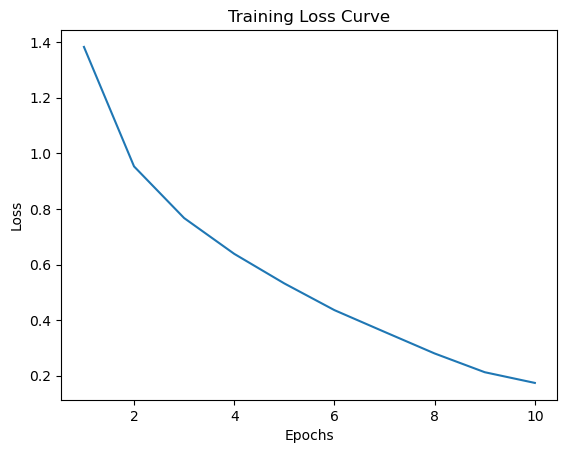

In [62]:
import matplotlib.pyplot as plt

plt.plot(range(1,epochs+1),losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [63]:
# Evaluate 

correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images,labels in testloader:
        outputs = model.forward(images)
        _, predicted = torch.max(outputs,1)
        correct_labels = (predicted == labels).sum().item()
        total_labels = labels.size(0)

print(f"Accuracy = {correct_labels/total_labels * 100}")

Accuracy = 75.0
